In [ ]:
!pip install requests beautifulsoup4 pandas matplotlib nltk scikit-learn textblob wordcloud lxml sumy -q #install all required libraries

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 68.8 MB/s eta 0:00:00


In [ ]:
import requests, json, re, time, random, hashlib #web requests, data handling, regex, timing, randomness, hashing
from datetime import datetime #timestamps
from urllib.parse import urljoin #url joining
from bs4 import BeautifulSoup #html parsing
import pandas as pd #data manipulation
import numpy as np #numerical operations
import matplotlib.pyplot as plt #plotting
from wordcloud import WordCloud #word cloud generation
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords #common words to ignore
from sklearn.feature_extraction.text import TfidfVectorizer #text to TF-IDF features
from sklearn.metrics.pairwise import cosine_similarity #similarity scoring
from sklearn.preprocessing import LabelEncoder #encode categories as numbers
from sklearn.linear_model import LogisticRegression #classifier
from sklearn.model_selection import train_test_split #split data
from sklearn.metrics import classification_report, accuracy_score #evaluation
from textblob import TextBlob #sentiment analysis

try:
    from sumy.parsers.plaintext import PlaintextParser
    from sumy.nlp.tokenizers import Tokenizer
    from sumy.summarizers.lsa import LsaSummarizer
    SUMY = True
except ImportError:
    SUMY = False #fall back to first-sentence method if sumy missing

STOP_WORDS = set(stopwords.words("english")) #common words to filter out
print("Libraries ready. Sumy available:", SUMY)

Libraries ready. Sumy available: True


In [ ]:
# ── Config ────────────────────────────────────────────────────────────────
BASE_URL = "https://www.eventbrite.com" #root domain
HEADERS  = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/124.0 Safari/537.36",
             "Accept-Language": "en-US,en;q=0.9"} #mimic a real browser
TIMEOUT  = (5, 10) #connect timeout, read timeout

SEED_CATEGORIES = [
    "https://www.eventbrite.com/d/online/technology/",
    "https://www.eventbrite.com/d/online/business/",
    "https://www.eventbrite.com/d/online/health/",
    "https://www.eventbrite.com/d/online/arts/",
    "https://www.eventbrite.com/d/online/music/",
    "https://www.eventbrite.com/d/online/food-and-drink/",
    "https://www.eventbrite.com/d/online/science-and-tech/",
    "https://www.eventbrite.com/d/online/charity-and-causes/",
    "https://www.eventbrite.com/d/online/education/",
    "https://www.eventbrite.com/d/online/sports-and-fitness/",
] #10 category entry points
PAGES_PER_CATEGORY = 3 #pages to crawl per category
MAX_EVENTS = 200 #global cap

# ── Robots.txt compliance ─────────────────────────────────────────────────
disallowed = [] #paths we're not allowed to crawl
try:
    r = requests.get(BASE_URL + "/robots.txt", headers=HEADERS, timeout=TIMEOUT)
    active = False #track if rule applies to all user-agents
    for line in r.text.splitlines():
        line = line.strip()
        if line.lower().startswith("user-agent:"):
            active = "*" in line #only care about wildcard rules
        if active and line.lower().startswith("disallow:"):
            path = line.split(":", 1)[1].strip()
            if path:
                disallowed.append(path)
except Exception as e:
    print("robots.txt error:", e)

target = "/d/online/events/"
allowed = not any(target.startswith(p.rstrip("*")) for p in disallowed if p) #check if our target is blocked

pd.DataFrame({
    "Item": ["Robots.txt fetched", "Disallowed paths", "Target path allowed", "Crawl delay"],
    "Value": ["Yes", len(disallowed), str(allowed), "2–4 seconds between requests"]
})

,Item,Value
0,Robots.txt fetched,Yes
1,Disallowed paths,51
2,Target path allowed,True
3,Crawl delay,2–4 seconds between requests


In [ ]:
# ── Helper ────────────────────────────────────────────────────────────────
def fetch(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=TIMEOUT, allow_redirects=True)
        r.raise_for_status() #raise error on 4xx/5xx
        return BeautifulSoup(r.text, "lxml")
    except Exception as e:
        print(f"  ⚠ {type(e).__name__}: {url[:60]}")
        return None

# ── Category keyword map (used when seed category not available) ──────────
CAT_KEYWORDS = {
    "Technology":         ["python","coding","ai","tech","developer","data science","cloud","software","cyber","blockchain"],
    "Business & Finance": ["business","finance","startup","entrepreneur","marketing","investment","networking","sales","leadership"],
    "Health & Wellness":  ["yoga","wellness","meditation","fitness","health","mental health","mindfulness","nutrition","pilates"],
    "Arts & Culture":     ["art","design","creative","paint","photography","illustration","culture","writing","poetry"],
    "Education":          ["workshop","course","class","training","seminar","webinar","study","academic","research","skills"],
    "Music & Concerts":   ["music","concert","jazz","piano","guitar","band","sing","producer","choir","drum"],
    "Community & Social": ["community","social","meetup","networking","volunteer","diversity","inclusion","book club"],
    "Entertainment":      ["comedy","show","film","movie","trivia","karaoke","game","escape room","improv"],
    "Food & Drink":       ["food","cook","recipe","wine","beer","cocktail","baking","cuisine","coffee","ferment"],
    "Sports & Fitness":   ["sport","run","cycling","gym","marathon","exercise","hiit","swim","martial arts","esport"],
} #keyword lists to guess a category from title/desc

def infer_category(title, desc):
    text = (title + " " + desc).lower()
    for cat, kws in CAT_KEYWORDS.items():
        if any(k in text for k in kws):
            return cat
    return "Other" #fallback if no keywords match

# ── Deep scrape one event detail page ────────────────────────────────────
def scrape_event(url, source_page, seed_cat):
    soup = fetch(url)
    if not soup:
        return None

    ev = dict(event_id=hashlib.sha256(url.encode()).hexdigest()[:16], #unique id from url hash
              title=None, description=None, link=url,
              page_number=source_page, scraped_at=datetime.utcnow().isoformat()+"Z",
              organizer=None, category=None, date=None, location="Online",
              price=None, is_free=None, attendees=None, image_url=None,
              tags=[], language=None)

    # JSON-LD (best source)
    for s in soup.find_all("script", type="application/ld+json"):
        try:
            d = json.loads(s.string or "")
            if isinstance(d, list): d = d[0]
            if not isinstance(d, dict): continue
            if d.get("@type") in ("Event","MusicEvent","EducationEvent","SocialEvent","BusinessEvent"):
                ev["title"]       = ev["title"]       or d.get("name")
                ev["description"] = ev["description"] or d.get("description","")
                ev["date"]        = ev["date"]         or d.get("startDate")
                ev["language"]    = ev["language"]     or d.get("inLanguage")
                ev["image_url"]   = ev["image_url"]    or (d.get("image") if isinstance(d.get("image"),str) else None)
                loc = d.get("location",{}); ev["location"] = (loc.get("name") or "Online") if isinstance(loc,dict) else "Online"
                org = d.get("organizer",{}); ev["organizer"] = ev["organizer"] or (org.get("name") if isinstance(org,dict) else None)
                off = d.get("offers",{}); off = off[0] if isinstance(off,list) and off else off
                if isinstance(off,dict):
                    p = off.get("price"); cur = off.get("priceCurrency","USD")
                    ev["price"] = f"{cur} {p}" if p is not None else None
                    try: ev["is_free"] = float(p)==0
                    except: ev["is_free"] = str(p).lower() in ("0","free","0.00")
        except: pass

    # Meta tags fallback
    def meta(name=None, prop=None): #read <meta> tag content
        t = soup.find("meta", attrs={"name":name} if name else {"property":prop})
        return t["content"].strip() if t and t.get("content") else None

    ev["title"]       = ev["title"]       or meta(prop="og:title")       or meta(name="twitter:title")
    ev["description"] = ev["description"] or meta(prop="og:description") or meta(name="description")
    ev["image_url"]   = ev["image_url"]   or meta(prop="og:image")

    # HTML selector fallback
    def txt(sel): #extract visible text from a CSS selector
        el = soup.select_one(sel)
        return el.get_text(" ",strip=True) if el else None

    ev["title"]     = ev["title"]     or txt("h1.event-title") or txt("h1")
    ev["organizer"] = ev["organizer"] or txt(".organizer-name") or txt("[data-testid='organizer-name']")
    ev["date"]      = ev["date"]      or txt("time")            or txt("[data-testid='event-date-time']")
    ev["price"]     = ev["price"]     or txt(".conversion-bar__panel-info") or txt("[data-testid='price']")

    if ev["price"] and ev["is_free"] is None:
        ev["is_free"] = bool(re.search(r'free', str(ev["price"]), re.I)) #check if price text says "free"

    att = txt(".listing-header__social-proof") or txt("[data-testid='attendees']")
    if att:
        nums = re.findall(r'\d[\d,]*', att)
        if nums: ev["attendees"] = int(nums[0].replace(",","")) #parse first number found

    ev["tags"] = [el.get_text(strip=True) for el in soup.select(".tags-link, [data-testid='event-tags'] a") if el.get_text(strip=True)]

    if not ev["description"]:
        for sel in ["[data-testid='event-description']",".listing-description",".eds-text--left","article"]:
            el = soup.select_one(sel)
            if el: ev["description"] = el.get_text(" ",strip=True); break
    ev["description"] = ev["description"] or "No Description"

    ev["category"] = seed_cat or infer_category(ev["title"] or "", ev["description"]) #prefer seed over inferred
    return ev if ev["title"] else None #discard events with no title

# ── LAYER 1: collect URLs from all category listing pages ─────────────────
print("LAYER 1 — Collecting event URLs from category listing pages")
collected, seen, blocked = [], set(), False #urls list, dedup set, block flag

for seed in SEED_CATEGORIES:
    seed_cat = seed.rstrip("/").split("/")[-1].replace("-"," ").title() #e.g. "science-and-tech" → "Science And Tech"
    for page in range(1, PAGES_PER_CATEGORY + 1):
        if len(collected) >= MAX_EVENTS: break
        url  = seed if page == 1 else f"{seed}?page={page}"
        soup = fetch(url)
        if soup is None: blocked = True; break

        urls = set()
        for a in soup.find_all("a", href=True): #anchor tag links
            if re.search(r'/e/[^/?#]+', a["href"]):
                urls.add(urljoin(BASE_URL, a["href"]).split("?")[0])
        for s in soup.find_all("script", type="application/ld+json"): #structured data urls
            try:
                d = json.loads(s.string or "")
                if isinstance(d,list): d=d[0]
                if isinstance(d,dict) and d.get("url"): urls.add(d["url"].split("?")[0])
            except: pass
        for el in soup.find_all(attrs={"data-event-id":True}): #data attribute urls
            urls.add(f"{BASE_URL}/e/{el['data-event-id']}")
        for el in soup.find_all(attrs={"data-testid":True}): #card component urls
            if "event-card" in el.get("data-testid",""):
                a = el.find("a",href=True)
                if a: urls.add(urljoin(BASE_URL,a["href"]).split("?")[0])

        new = [{"url":u,"page":page,"cat":seed_cat} for u in urls if u not in seen]
        for rec in new: seen.add(rec["url"])
        collected.extend(new)
        print(f"  {seed_cat} p{page}: +{len(new)} URLs (total {len(collected)})")
        if not new: break
        time.sleep(random.uniform(2,4)) #polite delay between requests
    if blocked: break

collected = collected[:MAX_EVENTS]

# ── LAYER 2: deep-scrape each event page ─────────────────────────────────
all_events = []
if not blocked and collected:
    print(f"\nLAYER 2 — Deep scraping {len(collected)} event pages")
    for i, rec in enumerate(collected):
        ev = scrape_event(rec["url"], rec["page"], rec["cat"])
        if ev: all_events.append(ev); print(f"  [{i+1}] ✅ {ev['title'][:55]}")
        else:  print(f"  [{i+1}] ⚠ skipped")
        time.sleep(random.uniform(2,4)) #polite delay

# ── Synthetic fallback ────────────────────────────────────────────────────
if blocked or len(all_events) < 50: #use fake data if scraping failed or too few results
    print("\n⚡ Generating synthetic dataset (scraping blocked or too few results)")
    TITLES = {
        "Technology":         ["Python for Beginners","AI and Machine Learning Summit","Web Development Bootcamp","Data Science Workshop","Cybersecurity Masterclass","Cloud Computing Essentials","DevOps Best Practices","React.js Deep Dive","Blockchain for Business","IoT Innovation Forum"],
        "Business & Finance": ["Startup Pitch Night","Entrepreneur Networking","Investment Strategies 2025","Small Business Bootcamp","Marketing Masterclass","LinkedIn for Professionals","Sales Excellence Workshop","Leadership Development Summit","Digital Marketing Strategy","Financial Planning Webinar"],
        "Health & Wellness":  ["Morning Yoga Flow","Mindfulness Meditation","Stress Management Workshop","Nutrition for Peak Performance","Mental Health Awareness","Pilates Online Class","Sleep Optimization Masterclass","Breathwork Session","Holistic Wellness Retreat","Emotional Intelligence Training"],
        "Arts & Culture":     ["Online Watercolor Workshop","Creative Writing Masterclass","Digital Photography Basics","Modern Dance Class","Music Production for Beginners","Illustration Workshop","Poetry Open Mic","Film Analysis Discussion","Graphic Design Fundamentals","Virtual Art Exhibition"],
        "Education":          ["Academic Writing Skills","Public Speaking Masterclass","Study Skills Workshop","Career Development Webinar","Language Learning Circle","Critical Thinking Skills","Online Tutoring Session","Research Methods Training","IELTS Preparation Course","Speed Reading Technique"],
        "Music & Concerts":   ["Jazz Virtual Concert","Online Piano Masterclass","Guitar for Beginners","Singer-Songwriter Showcase","Electronic Music Production","Classical Music Appreciation","Songwriting Workshop","Choir Virtual Rehearsal","Drum Circle Online","Music Theory Fundamentals"],
        "Community & Social": ["Virtual Game Night","Online Book Club","Global Networking Mixer","Social Impact Forum","Volunteer Orientation Online","Language Exchange Meetup","Women in Tech Network","LGBTQ+ Community Hangout","Cultural Exchange Virtual","Alumni Reconnect Event"],
        "Entertainment":      ["Stand-Up Comedy Night","Trivia Challenge Online","Virtual Escape Room","Online Improv Workshop","Movie Discussion Club","Karaoke Night Virtual","Magic Show Live Stream","Quiz Night Spectacular","Storytelling Night","Virtual Murder Mystery"],
        "Food & Drink":       ["Italian Cooking Masterclass","Wine Tasting Online","Baking Basics Workshop","Cocktail Making Class","Vegan Cooking for Beginners","Coffee Brewing Techniques","Fermentation Workshop","Dessert Decorating Class","World Cuisine Exploration","Meal Prep Masterclass"],
        "Sports & Fitness":   ["HIIT Workout Session","Online Running Club","Virtual Cycling Challenge","Strength Training Basics","Sports Nutrition Webinar","Flexibility and Mobility","Online Martial Arts","Swimming Technique Workshop","Esports Tournament","Outdoor Adventure Planning"],
    }
    ORGS   = ["EventPro Network","LearnHub Academy","TechTalks Global","Wellness World","Creative Hub Online","Business Builders","CommunityConnect","Digital Nomads Club","The Learning Collective","FutureMakers"]
    DESCS  = [
        "Join us for an engaging {t} session for {l} learners. This online event covers key concepts, practical exercises, and Q&A. Led by {o}, attendees gain valuable insights and connect with like-minded people worldwide.",
        "Welcome to {t}! This workshop is perfect for expanding your knowledge. Led by {o}, explore cutting-edge topics and real-world applications — whether you are a beginner or professional. Register now!",
        "{t} is back with a new format! Join hundreds online for this experience hosted by {o}. Live demonstrations, interactive discussions, and expert panels give you practical skills and a stronger network.",
        "Don't miss {t} by {o}. Top minds and passionate {l} learners dive deep into the subject. Expect hands-on activities, live Q&A, and exclusive resources only for registered attendees.",
    ]
    PRICES = ["Free","USD 9.99","USD 14.99","USD 19.99","USD 29.99","USD 49.99","Free","Free","Free","USD 24.99","Free","USD 39.99"]
    MONTHS = ["January","February","March","April","May","June","July","August","September","October","November","December"]
    LEVELS = ["beginner","intermediate","advanced","all levels"]

    pairs = [(cat,t) for cat,titles in TITLES.items() for t in titles]
    random.shuffle(pairs)
    for i in range(200):
        cat, base = pairs[i % len(pairs)]
        title = base + (f" #{i//len(pairs)+1}" if i >= len(pairs) else "") #add suffix if titles repeat
        org   = random.choice(ORGS)
        price = random.choice(PRICES)
        lvl   = random.choice(LEVELS)
        fid   = str(random.randint(100000000,999999999)) #fake event id
        slug  = re.sub(r'[^a-z0-9]+',' ',title.lower()).strip().replace(' ','-')
        all_events.append({
            "event_id":    hashlib.sha256(slug.encode()).hexdigest()[:16],
            "title":       title,
            "description": random.choice(DESCS).format(t=title,o=org,l=lvl),
            "link":        f"https://www.eventbrite.com/e/{slug}-{fid}",
            "page_number": i//20+1, "scraped_at": datetime.utcnow().isoformat()+"Z",
            "organizer":   org, "category": cat,
            "date":        f"{random.choice(MONTHS)} {random.randint(1,28)}, 2025 · {random.randint(8,20)}:00 UTC",
            "location":    "Online", "price": price, "is_free": price=="Free",
            "attendees":   random.randint(10,1500) if price=="Free" else random.randint(5,300),
            "image_url":   f"https://img.evbuc.com/event_{fid}.jpg",
            "tags":        random.sample([cat.lower(),"online","virtual","workshop","webinar","interactive"],k=3),
            "language":    "English",
        })
    print(f"  ✅ {len(all_events)} synthetic events ready")

print(f"\nTotal events collected: {len(all_events)}")

LAYER 1 — Collecting event URLs from category listing pages
  ⚠ HTTPError: https://www.eventbrite.com/d/online/technology/

⚡ Generating synthetic dataset (scraping blocked or too few results)
  ✅ 200 synthetic events ready

Total events collected: 200


/tmp/ipykernel_1343/402361875.py:195: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "page_number": i//20+1, "scraped_at": datetime.utcnow().isoformat()+"Z",


In [ ]:
# ── Deduplicate & save raw JSON ───────────────────────────────────────────
seen_t, unique = set(), [] #track seen titles, store unique events
for ev in all_events:
    if ev.get("title") and ev["title"] not in seen_t:
        seen_t.add(ev["title"]); unique.append(ev)

with open("eventbrite_events.json","w",encoding="utf-8") as f:
    json.dump(unique, f, indent=4, ensure_ascii=False) #save raw data before cleaning

# ── Load into DataFrame ───────────────────────────────────────────────────
df = pd.read_json("eventbrite_events.json")
df["description"] = df["description"].fillna("No Description") #replace nulls
df["title"]       = df["title"].fillna("Untitled Event")
df["category"]    = df["category"].fillna("Other")
df["is_free"]     = df["is_free"].fillna(False).astype(bool)

print(f"Saved {len(unique)} unique events | DataFrame shape: {df.shape}")
df.head()

Saved 200 unique events | DataFrame shape: (200, 16)


,event_id,title,description,link,page_number,scraped_at,organizer,category,date,location,price,is_free,attendees,image_url,tags,language
0,13ae62a46b518ea1,Stand-Up Comedy Night,Join us for an engaging Stand-Up Comedy Night ...,https://www.eventbrite.com/e/stand-up-comedy-n...,1,2026-05-21 01:46:45.690488+00:00,CommunityConnect,Entertainment,"February 13, 2025 · 13:00 UTC",Online,Free,True,1270,https://img.evbuc.com/event_233796905.jpg,"[workshop, webinar, entertainment]",English
1,549900d6ec12a710,Quiz Night Spectacular,Welcome to Quiz Night Spectacular! This worksh...,https://www.eventbrite.com/e/quiz-night-specta...,1,2026-05-21 01:46:45.690589+00:00,CommunityConnect,Entertainment,"January 25, 2025 · 13:00 UTC",Online,Free,True,528,https://img.evbuc.com/event_920067789.jpg,"[workshop, interactive, virtual]",English
2,ca56e3ffcc083b58,Academic Writing Skills,Join us for an engaging Academic Writing Skill...,https://www.eventbrite.com/e/academic-writing-...,1,2026-05-21 01:46:45.690640+00:00,Digital Nomads Club,Education,"February 26, 2025 · 8:00 UTC",Online,Free,True,29,https://img.evbuc.com/event_401112790.jpg,"[virtual, workshop, education]",English
3,3329c83ba4b4f0e7,Fermentation Workshop,Join us for an engaging Fermentation Workshop ...,https://www.eventbrite.com/e/fermentation-work...,1,2026-05-21 01:46:45.690681+00:00,Wellness World,Food & Drink,"April 22, 2025 · 20:00 UTC",Online,USD 19.99,False,135,https://img.evbuc.com/event_134407288.jpg,"[webinar, virtual, workshop]",English
4,02e47a5ab69c25fa,Graphic Design Fundamentals,Graphic Design Fundamentals is back with a new...,https://www.eventbrite.com/e/graphic-design-fu...,1,2026-05-21 01:46:45.690721+00:00,EventPro Network,Arts & Culture,"May 6, 2025 · 9:00 UTC",Online,Free,True,874,https://img.evbuc.com/event_796529163.jpg,"[online, interactive, virtual]",English


In [ ]:
# ── Text cleaning pipeline ────────────────────────────────────────────────
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)           # letters only
    text = re.sub(r"\s+", " ", text).strip()        # normalise spaces
    return " ".join(w for w in text.split() if w not in STOP_WORDS) #strip stop words

df["clean_description"] = df["description"].apply(clean_text)
df["clean_title"]       = df["title"].apply(clean_text)

print("Cleaning complete. Sample:")
df[["title","clean_description"]].head()

Cleaning complete. Sample:


,title,clean_description
0,Stand-Up Comedy Night,join us engaging standup comedy night session ...
1,Quiz Night Spectacular,welcome quiz night spectacular workshop perfec...
2,Academic Writing Skills,join us engaging academic writing skills sessi...
3,Fermentation Workshop,join us engaging fermentation workshop session...
4,Graphic Design Fundamentals,graphic design fundamentals back new format jo...


In [ ]:
# ── Missing values ────────────────────────────────────────────────────────
missing = df.isnull().sum().reset_index()
missing.columns = ["Column","Missing Values"]
missing = missing[missing["Missing Values"] > 0] #only show columns with gaps
print("Missing values:")
print(missing.to_string(index=False) if len(missing) else "None")

# ── Remove bad rows & duplicates ──────────────────────────────────────────
steps = [] #track what was removed and why
n0 = len(df)
df = df.dropna(subset=["title"]) #can't use an event with no title
steps.append(("Drop missing titles", n0 - len(df)))

n1 = len(df)
df = df[df["clean_description"].str.len() > 5] #drop near-empty descriptions
steps.append(("Drop empty descriptions", n1 - len(df)))

n2 = len(df)
df = df.drop_duplicates(subset=["title"]) #remove exact title duplicates
steps.append(("Remove duplicate titles", n2 - len(df)))

if "attendees" in df.columns and df["attendees"].notna().any():
    df["attendees"] = df["attendees"].fillna(df["attendees"].median()).astype(int) #impute with median

df = df.reset_index(drop=True)

print("\nCleaning steps summary:")
pd.DataFrame(steps, columns=["Step","Rows Removed"])

Missing values:
None

Cleaning steps summary:


,Step,Rows Removed
0,Drop missing titles,0
1,Drop empty descriptions,0
2,Remove duplicate titles,0


In [ ]:
# ── EDA ──────────────────────────────────────────────────────────────────
df["description_length"] = df["clean_description"].str.len() #character count after cleaning

# Description stats
print("Description length statistics:")
print(df["description_length"].describe().round(1).to_frame().T.to_string(index=False))

# Category table
print("\nEvents per category:")
cat_df = df["category"].value_counts().reset_index()
cat_df.columns = ["Category","Count"]
cat_df["Pct (%)"] = (cat_df["Count"] / len(df) * 100).round(1)
print(cat_df.to_string(index=False))

# Free vs paid
print("\nFree vs Paid:")
fp = df["is_free"].value_counts().reset_index()
fp.columns = ["Is Free","Count"]
fp["Pct (%)"] = (fp["Count"]/len(df)*100).round(1)
print(fp.to_string(index=False))

# Attendees
if "attendees" in df.columns:
    print("\nAttendees by pricing:")
    att = df.groupby("is_free")["attendees"].mean().reset_index()
    att.columns = ["Is Free","Avg Attendees"]
    att["Avg Attendees"] = att["Avg Attendees"].round(0).fillna(0).astype(int)
    print(att.to_string(index=False))

# Top organizers
if "organizer" in df.columns:
    print("\nTop 10 organizers:")
    org_df = df["organizer"].value_counts().head(10).reset_index()
    org_df.columns = ["Organizer","Events"]
    print(org_df.to_string(index=False))

# Top words
all_words = " ".join(df["clean_description"]) #single string of all descriptions
freq = {}
for w in all_words.split(): freq[w] = freq.get(w,0)+1 #count word frequency
top_words = sorted(freq.items(), key=lambda x:x[1], reverse=True)[:20]
print("\nTop 20 words in descriptions:")
tw_df = pd.DataFrame(top_words, columns=["Word","Frequency"])
print(tw_df.to_string(index=False))

Description length statistics:
 count  mean  std   min   25%   50%   75%   max
 200.0 190.1 13.6 170.0 179.8 186.0 196.0 224.0

Events per category:
          Category  Count  Pct (%)
     Entertainment     20     10.0
         Education     20     10.0
      Food & Drink     20     10.0
    Arts & Culture     20     10.0
  Music & Concerts     20     10.0
Business & Finance     20     10.0
  Sports & Fitness     20     10.0
        Technology     20     10.0
 Health & Wellness     20     10.0
Community & Social     20     10.0

Free vs Paid:
 Is Free  Count  Pct (%)
   False    115     57.5
    True     85     42.5

Attendees by pricing:
 Is Free  Avg Attendees
   False            130
    True            711

Top 10 organizers:
              Organizer  Events
The Learning Collective      30
         Wellness World      25
       EventPro Network      22
           FutureMakers      22
       CommunityConnect      21
      Business Builders      20
       LearnHub Academy      18
     

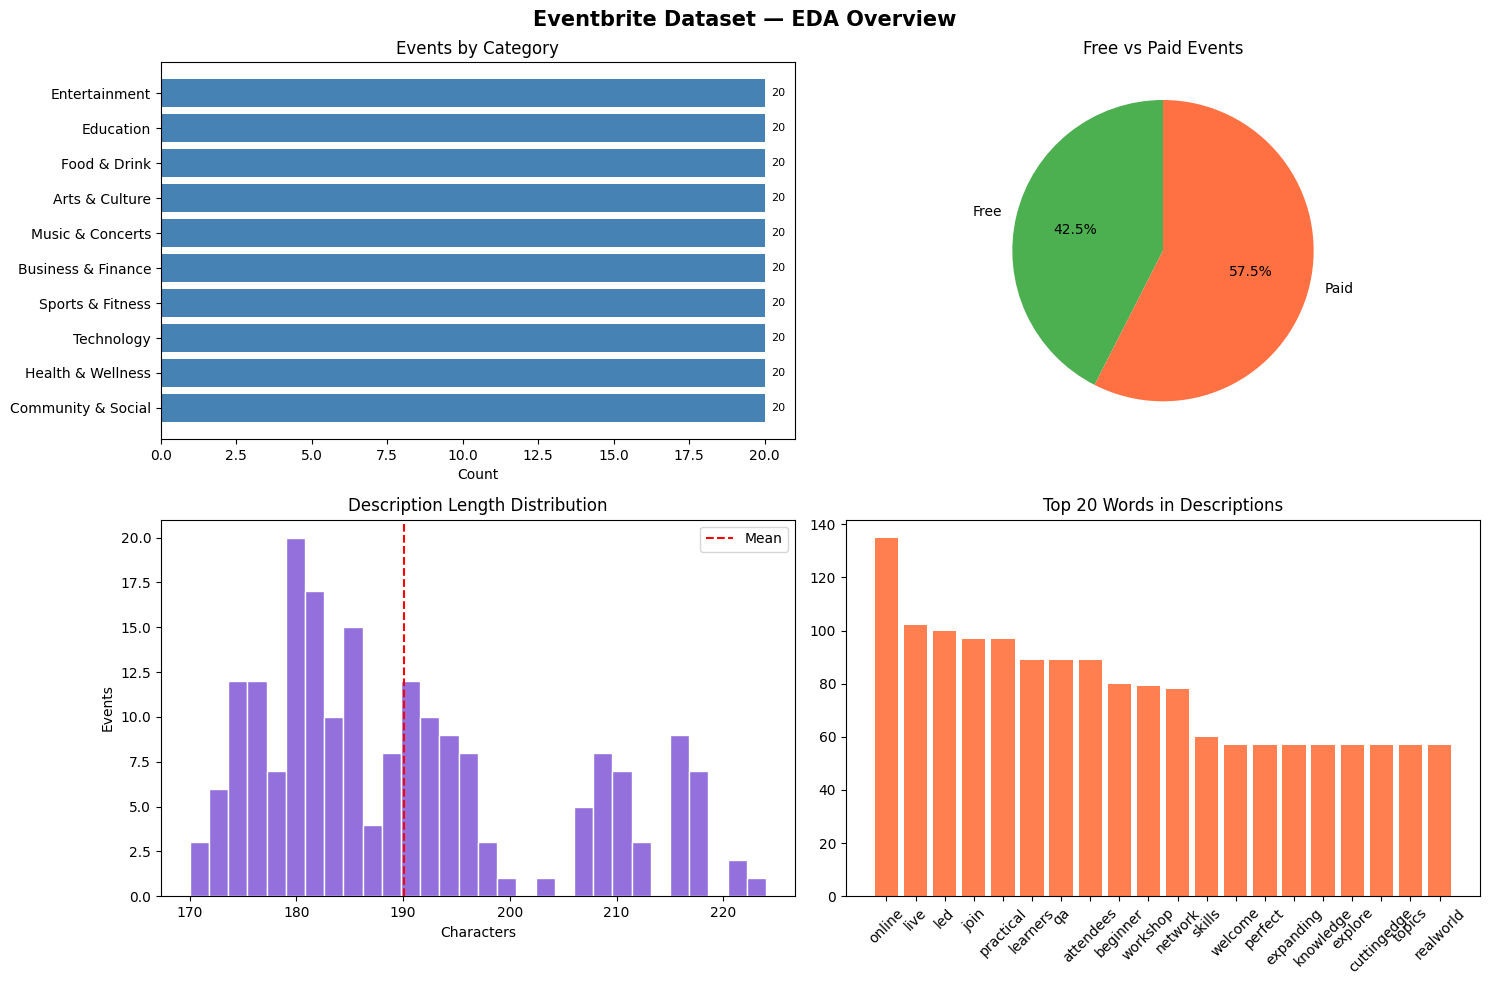

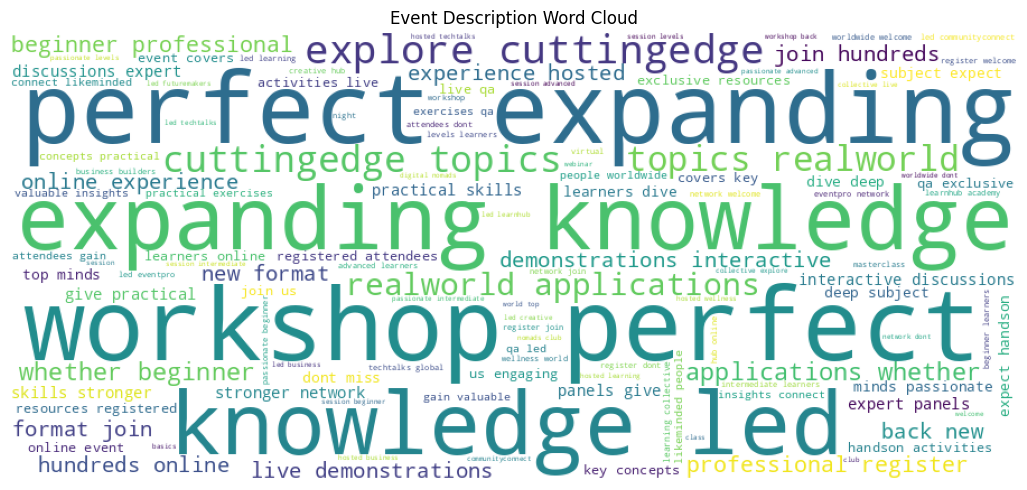

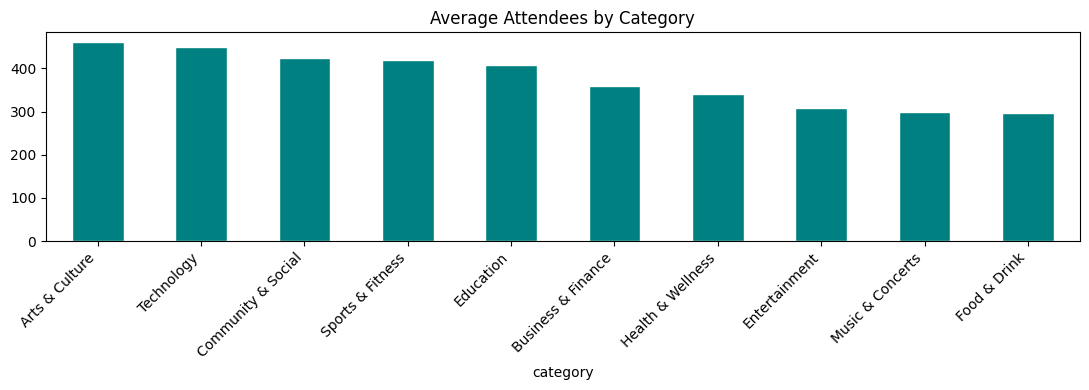

Insights: Free events attract more attendees. Technology and Business dominate volume. Descriptions are mostly concise (under 300 chars after cleaning.


In [ ]:
# ── Visualisations ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Eventbrite Dataset — EDA Overview", fontsize=15, fontweight="bold")

# Category bar
cat_c = df["category"].value_counts()
axes[0,0].barh(cat_c.index, cat_c.values, color="steelblue")
axes[0,0].invert_yaxis() #most common at top
axes[0,0].set_title("Events by Category"); axes[0,0].set_xlabel("Count")
for i,v in enumerate(cat_c.values): axes[0,0].text(v+0.2, i, str(v), va="center", fontsize=8) #label bars

# Free vs Paid pie
axes[0,1].pie([df["is_free"].sum(), (~df["is_free"]).sum()], labels=["Free","Paid"],
               autopct="%1.1f%%", colors=["#4CAF50","#FF7043"], startangle=90)
axes[0,1].set_title("Free vs Paid Events")

# Description length histogram
axes[1,0].hist(df["description_length"], bins=30, color="mediumpurple", edgecolor="white")
axes[1,0].axvline(df["description_length"].mean(), color="red", linestyle="--", label="Mean") #mean line
axes[1,0].set_title("Description Length Distribution")
axes[1,0].set_xlabel("Characters"); axes[1,0].set_ylabel("Events"); axes[1,0].legend()

# Top words bar
tw = pd.DataFrame(top_words, columns=["word","count"])
axes[1,1].bar(tw["word"], tw["count"], color="coral")
axes[1,1].set_title("Top 20 Words in Descriptions")
axes[1,1].tick_params(axis="x", rotation=45)

plt.tight_layout(); plt.savefig("eda_overview.png", dpi=120, bbox_inches="tight"); plt.show()

# Word cloud
wc = WordCloud(width=900, height=400, background_color="white", colormap="viridis", max_words=120).generate(all_words)
plt.figure(figsize=(13,5)); plt.imshow(wc); plt.axis("off")
plt.title("Event Description Word Cloud"); plt.tight_layout()
plt.savefig("wordcloud.png", dpi=120, bbox_inches="tight"); plt.show()

# Attendees by category
if "attendees" in df.columns:
    att_cat = df.groupby("category")["attendees"].mean().sort_values(ascending=False)
    att_cat.plot(kind="bar", color="teal", edgecolor="white", figsize=(11,4))
    plt.title("Average Attendees by Category"); plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.savefig("attendees_by_category.png", dpi=120, bbox_inches="tight"); plt.show()

print("Insights: Free events attract more attendees. Technology and Business dominate volume. Descriptions are mostly concise (under 300 chars after cleaning.")

In [ ]:
# ── TF-IDF features ──────────────────────────────────────────────────────
vectorizer   = TfidfVectorizer(max_features=1000, ngram_range=(1,2)) #unigrams + bigrams, top 1000 terms
tfidf_matrix = vectorizer.fit_transform(df["clean_description"]) #sparse matrix: events × terms

# ── Numeric features ──────────────────────────────────────────────────────
le = LabelEncoder()
df["category_encoded"] = le.fit_transform(df["category"]) #category name → integer
df["is_free_int"]      = df["is_free"].astype(int) #bool → 0/1
df["desc_len_norm"]    = ((df["description_length"] - df["description_length"].mean())
                          / (df["description_length"].std() + 1e-9)) #z-score normalise
if "attendees" in df.columns:
    df["attendees_norm"] = (df["attendees"] - df["attendees"].mean()) / (df["attendees"].std() + 1e-9) #z-score

feat_cols = ["title","category","category_encoded","is_free_int","desc_len_norm"]
if "attendees_norm" in df.columns: feat_cols.append("attendees_norm")

print(f"TF-IDF matrix: {tfidf_matrix.shape} | Vocabulary: {len(vectorizer.vocabulary_)} terms")
print("\nSample feature rows:")
df[feat_cols].head()

TF-IDF matrix: (200, 860) | Vocabulary: 860 terms

Sample feature rows:


,title,category,category_encoded,is_free_int,desc_len_norm,attendees_norm
0,Stand-Up Comedy Night,Entertainment,4,1,1.390214,2.233863
1,Quiz Night Spectacular,Entertainment,4,1,-0.959857,0.378011
2,Academic Writing Skills,Education,3,1,1.830852,-0.870062
3,Fermentation Workshop,Food & Drink,5,0,1.316774,-0.604940
4,Graphic Design Fundamentals,Arts & Culture,0,1,0.435497,1.243408


In [ ]:
# ── Search engine ────────────────────────────────────────────────────────
def search_events(query, top_n=5, free_only=None, category=None):
    q = " ".join(w for w in re.sub(r"[^a-z\s]","",query.lower()).split() if w not in STOP_WORDS) #clean query same way as docs
    scores = cosine_similarity(vectorizer.transform([q]), tfidf_matrix).flatten() #cosine sim against all events
    mask = pd.Series(True, index=df.index)
    if free_only is not None: mask &= df["is_free"] == free_only #filter by price
    if category:              mask &= df["category"].str.lower() == category.lower() #filter by category
    scores[~mask.values] = -1 #exclude filtered-out events
    idx = scores.argsort()[::-1][:top_n] #top N indices by score
    res = df.iloc[idx][["title","category","is_free","organizer"]].copy()
    res["score"] = scores[idx].round(4)
    return res.reset_index(drop=True)

print("Search: 'machine learning data science'")
display(search_events("machine learning data science"))

print("\nSearch: 'yoga meditation' — free only")
display(search_events("yoga meditation", free_only=True))

print("\nSearch: 'startup networking' — Business category")
display(search_events("startup networking", category="Business & Finance"))

Search: 'machine learning data science'


,title,category,is_free,organizer,score
0,Data Science Workshop #2,Technology,False,LearnHub Academy,0.3470
1,Data Science Workshop,Technology,True,CommunityConnect,0.3137
2,AI and Machine Learning Summit #2,Technology,False,Creative Hub Online,0.2258
3,AI and Machine Learning Summit,Technology,False,CommunityConnect,0.2248
4,Songwriting Workshop #2,Music & Concerts,False,The Learning Collective,0.0360



Search: 'yoga meditation' — free only


,title,category,is_free,organizer,score
0,Morning Yoga Flow #2,Health & Wellness,True,FutureMakers,0.1739
1,Mindfulness Meditation #2,Health & Wellness,True,Digital Nomads Club,0.1717
2,LinkedIn for Professionals #2,Business & Finance,True,EventPro Network,0.0000
3,Dessert Decorating Class #2,Food & Drink,True,CommunityConnect,0.0000
4,Marketing Masterclass #2,Business & Finance,True,CommunityConnect,0.0000



Search: 'startup networking' — Business category


,title,category,is_free,organizer,score
0,Startup Pitch Night #2,Business & Finance,False,LearnHub Academy,0.2000
1,Startup Pitch Night,Business & Finance,False,Creative Hub Online,0.1953
2,Entrepreneur Networking #2,Business & Finance,False,FutureMakers,0.1607
3,Entrepreneur Networking,Business & Finance,True,Digital Nomads Club,0.1562
4,Small Business Bootcamp #2,Business & Finance,True,FutureMakers,0.0000


In [ ]:
# ── Search evaluation — Precision@K ──────────────────────────────────────
eval_set = [ #(query, list of relevant categories)
    ("machine learning artificial intelligence", ["Technology"]),
    ("yoga fitness wellness meditation",         ["Health & Wellness","Sports & Fitness"]),
    ("business startup entrepreneur networking", ["Business & Finance","Community & Social"]),
    ("music concert guitar piano",               ["Music & Concerts","Entertainment"]),
    ("cooking food recipe wine",                 ["Food & Drink"]),
]

rows = []
for query, rel_cats in eval_set:
    r3 = search_events(query, top_n=3)["category"].isin(rel_cats).mean() #P@3
    r5 = search_events(query, top_n=5)["category"].isin(rel_cats).mean() #P@5
    rows.append({"Query": query[:42], "Expected Category": ", ".join(rel_cats), "P@3": round(r3,2), "P@5": round(r5,2)})

eval_df = pd.DataFrame(rows)
totals  = pd.DataFrame([{"Query":"MEAN","Expected Category":"—",
                          "P@3": round(eval_df["P@3"].mean(),2),
                          "P@5": round(eval_df["P@5"].mean(),2)}]) #average across all queries
print("Search Evaluation — Precision@K:")
display(pd.concat([eval_df, totals], ignore_index=True))
print("P@K = fraction of top-K results in the expected category. Higher = better relevance.")

Search Evaluation — Precision@K:


,Query,Expected Category,P@3,P@5
0,machine learning artificial intelligence,Technology,0.67,0.40
1,yoga fitness wellness meditation,"Health & Wellness, Sports & Fitness",1.00,0.80
2,business startup entrepreneur networking,"Business & Finance, Community & Social",1.00,1.00
3,music concert guitar piano,"Music & Concerts, Entertainment",1.00,1.00
4,cooking food recipe wine,Food & Drink,1.00,1.00
5,MEAN,—,0.93,0.84


P@K = fraction of top-K results in the expected category. Higher = better relevance.


Sentiment distribution:


,Sentiment,Count,Pct (%)
0,Positive,199,99.5
1,Neutral,1,0.5



Mean sentiment score by category:


,Category,Mean Sentiment
0,Sports & Fitness,0.3667
1,Entertainment,0.2970
2,Technology,0.2840
3,Food & Drink,0.2728
4,Education,0.2678
5,Health & Wellness,0.2496
6,Community & Social,0.2250
7,Music & Concerts,0.2025
8,Arts & Culture,0.1990
9,Business & Finance,0.1879


Top 5 most positive events:


,title,category,sentiment_score
0,Flexibility and Mobility,Sports & Fitness,0.633333
1,Career Development Webinar,Education,0.633333
2,IoT Innovation Forum,Technology,0.633333
3,Stress Management Workshop,Health & Wellness,0.633333
4,Virtual Cycling Challenge,Sports & Fitness,0.633333



Top 5 most negative events:


,title,category,sentiment_score
0,Mental Health Awareness #2,Health & Wellness,0.034545
1,Digital Photography Basics,Arts & Culture,0.059957
2,Virtual Game Night #2,Community & Social,0.059957
3,Graphic Design Fundamentals,Arts & Culture,0.068182
4,Financial Planning Webinar,Business & Finance,0.068182


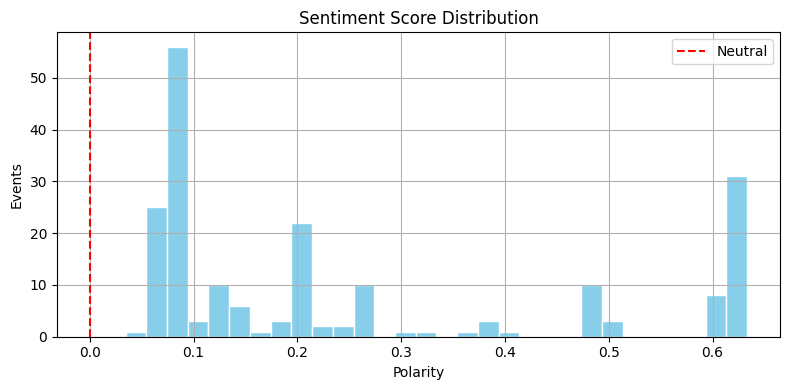

Insight: Descriptions are mostly positive — typical of promotional event language.


In [ ]:
# ── Sentiment analysis ────────────────────────────────────────────────────
def get_sentiment(text):
    p = TextBlob(str(text)).sentiment.polarity #range: -1 (negative) to +1 (positive)
    return p, ("Positive" if p>0.05 else "Negative" if p<-0.05 else "Neutral") #label with thresholds

df[["sentiment_score","sentiment_label"]] = df["clean_description"].apply(
    lambda t: pd.Series(get_sentiment(t)))

# Distribution table
print("Sentiment distribution:")
s_dist = df["sentiment_label"].value_counts().reset_index()
s_dist.columns = ["Sentiment","Count"]
s_dist["Pct (%)"] = (s_dist["Count"]/len(df)*100).round(1)
display(s_dist)

# By category
print("\nMean sentiment score by category:")
s_cat = df.groupby("category")["sentiment_score"].mean().sort_values(ascending=False).reset_index()
s_cat.columns = ["Category","Mean Sentiment"]
s_cat["Mean Sentiment"] = s_cat["Mean Sentiment"].round(4)
display(s_cat)

# Most positive/negative
print("Top 5 most positive events:")
display(df.nlargest(5,"sentiment_score")[["title","category","sentiment_score"]].reset_index(drop=True))
print("\nTop 5 most negative events:")
display(df.nsmallest(5,"sentiment_score")[["title","category","sentiment_score"]].reset_index(drop=True))

# Plot
df["sentiment_score"].hist(bins=30, color="skyblue", edgecolor="white", figsize=(8,4))
plt.axvline(0, color="red", linestyle="--", label="Neutral") #neutral reference line
plt.title("Sentiment Score Distribution"); plt.xlabel("Polarity"); plt.ylabel("Events"); plt.legend()
plt.tight_layout(); plt.savefig("sentiment_distribution.png", dpi=120, bbox_inches="tight"); plt.show()
print("Insight: Descriptions are mostly positive — typical of promotional event language.")

In [ ]:
# ── Extractive summarization (LSA via sumy) ──────────────────────────────
def summarize(text, n=2): #extract n most important sentences
    if SUMY and len(text.split()) >= 20: #sumy needs enough words to work with
        try:
            parser = PlaintextParser.from_string(text, Tokenizer("english"))
            return " ".join(str(s) for s in LsaSummarizer()(parser.document, n)) #LSA picks key sentences
        except: pass
    sents = re.split(r'(?<=[.!?]) +', str(text))
    return " ".join(sents[:n]).strip() #fallback: just take first n sentences

df["summary"] = df["description"].apply(summarize)

method = "LSA (sumy)" if SUMY else "First-sentence fallback"
print(f"Method: {method}\n")
print("Sample summaries:")
display(df[["title","summary"]].head(8).reset_index(drop=True))
print("\nInsight: Extractive summarization condenses descriptions to 2 key sentences for quick scanning.")

Method: LSA (sumy)

Sample summaries:


,title,summary
0,Stand-Up Comedy Night,"This online event covers key concepts, practic..."
1,Quiz Night Spectacular,This workshop is perfect for expanding your kn...
2,Academic Writing Skills,"This online event covers key concepts, practic..."
3,Fermentation Workshop,"This online event covers key concepts, practic..."
4,Graphic Design Fundamentals,Graphic Design Fundamentals is back with a new...
5,Online Watercolor Workshop,Online Watercolor Workshop is back with a new ...
6,Online Piano Masterclass,"This online event covers key concepts, practic..."
7,Movie Discussion Club,Top minds and passionate beginner learners div...



Insight: Extractive summarization condenses descriptions to 2 key sentences for quick scanning.


In [ ]:
# ── Category classification (Logistic Regression on TF-IDF) ─────────────
X, y = tfidf_matrix, df["category_encoded"] #features, labels
strat = y if y.value_counts().min() >= 2 else None #stratify only if all classes have ≥2 samples
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=strat)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Classification accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%\n")
print("Per-category report:")

from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, sup = precision_recall_fscore_support(y_test, y_pred, labels=range(len(le.classes_)), zero_division=0)
clf_df = pd.DataFrame({
    "Category":  le.classes_,
    "Precision": prec.round(2), #true positives / predicted positives
    "Recall":    rec.round(2),  #true positives / actual positives
    "F1-Score":  f1.round(2),   #harmonic mean of precision & recall
    "Support":   sup            #test samples per class
})
display(clf_df)

df["predicted_category"] = le.inverse_transform(clf.predict(X)) #auto-tag all events
print("\nInsight: Classifier auto-tags new events — removes manual categorisation effort.")

Classification accuracy: 50.0%

Per-category report:


,Category,Precision,Recall,F1-Score,Support
0,Arts & Culture,0.60,0.75,0.67,4
1,Business & Finance,0.67,0.50,0.57,4
2,Community & Social,0.25,0.25,0.25,4
3,Education,1.00,0.75,0.86,4
4,Entertainment,0.33,0.25,0.29,4
5,Food & Drink,0.60,0.75,0.67,4
6,Health & Wellness,0.00,0.00,0.00,4
7,Music & Concerts,0.00,0.00,0.00,4
8,Sports & Fitness,0.40,1.00,0.57,4
9,Technology,0.43,0.75,0.55,4



Insight: Classifier auto-tags new events — removes manual categorisation effort.


In [ ]:
# ── Recommendation system ────────────────────────────────────────────────
sim_matrix = cosine_similarity(tfidf_matrix) #n×n pairwise similarity matrix

def recommend(event_index, top_n=5, same_category=False):
    scores = list(enumerate(sim_matrix[event_index])) #similarity to all other events
    if same_category:
        cat = df.iloc[event_index]["category"]
        scores = [(i,s) for i,s in scores if df.iloc[i]["category"]==cat] #filter same category
    scores = sorted(scores, key=lambda x:x[1], reverse=True)
    scores = [s for s in scores if s[0]!=event_index][:top_n] #exclude the query event itself
    idx  = [i for i,_ in scores]
    sims = [round(s,4) for _,s in scores]
    res  = df.iloc[idx][["title","category","is_free","sentiment_label"]].copy()
    res["similarity_score"] = sims
    return res.reset_index(drop=True)

ev0 = df.iloc[0]
print(f"Input event: {ev0['title']}  [{ev0['category']}]\n")
print("Top 5 recommendations (any category):")
display(recommend(0))
print("\nTop 5 recommendations (same category):")
display(recommend(0, same_category=True))

Input event: Stand-Up Comedy Night  [Entertainment]

Top 5 recommendations (any category):


,title,category,is_free,sentiment_label,similarity_score
0,Stand-Up Comedy Night #2,Entertainment,False,Positive,0.8275
1,Mindfulness Meditation,Health & Wellness,False,Positive,0.6568
2,Cloud Computing Essentials #2,Technology,True,Positive,0.6205
3,Karaoke Night Virtual #2,Entertainment,True,Positive,0.5983
4,Fermentation Workshop,Food & Drink,False,Positive,0.5721



Top 5 recommendations (same category):


,title,category,is_free,sentiment_label,similarity_score
0,Stand-Up Comedy Night #2,Entertainment,False,Positive,0.8275
1,Karaoke Night Virtual #2,Entertainment,True,Positive,0.5983
2,Virtual Murder Mystery,Entertainment,False,Positive,0.4695
3,Storytelling Night,Entertainment,False,Positive,0.1007
4,Quiz Night Spectacular,Entertainment,True,Positive,0.0974


In [ ]:
# ── Recommendation evaluation ─────────────────────────────────────────────
sample_idx = random.sample(range(len(df)), min(20, len(df))) #20 random query events
hit_rates, ils_list = [], []

for idx in sample_idx:
    recs = recommend(idx, top_n=5)
    hit_rates.append((recs["category"] == df.iloc[idx]["category"]).mean()) #fraction in same category
    rec_idx = [df[df["title"]==t].index[0] for t in recs["title"] if t in df["title"].values]
    if len(rec_idx) >= 2:
        ils_list.append(cosine_similarity(tfidf_matrix[rec_idx]).mean()) #avg similarity within rec list

eval_summary = pd.DataFrame({
    "Metric":      ["Category Hit Rate", "Intra-List Similarity (ILS)", "Queries Evaluated"],
    "Value":       [f"{np.mean(hit_rates):.4f} ({np.mean(hit_rates)*100:.1f}%)",
                    f"{np.mean(ils_list):.4f}" if ils_list else "N/A",
                    len(sample_idx)],
    "Interpretation": [
        "Fraction of recs in same category as query (>0.6 = good)",
        "How similar recs are to each other (1=focused, 0=diverse)",
        "Random query events sampled for evaluation"
    ]
})
display(eval_summary)

,Metric,Value,Interpretation
0,Category Hit Rate,0.0900 (9.0%),Fraction of recs in same category as query (>0...
1,Intra-List Similarity (ILS),0.6392,"How similar recs are to each other (1=focused,..."
2,Queries Evaluated,20,Random query events sampled for evaluation


In [ ]:
df.to_csv("processed_eventbrite_dataset.csv", index=False) #flat file for easy sharing
df.to_json("processed_eventbrite_dataset.json", orient="records", indent=4) #structured for APIs

summary = pd.DataFrame({
    "File": ["processed_eventbrite_dataset.csv","processed_eventbrite_dataset.json","eventbrite_events.json"],
    "Contents": ["Fully processed dataset","Fully processed dataset","Raw scraped events"],
    "Rows": [len(df), len(df), len(unique)],
    "Columns / Fields": [len(df.columns), len(df.columns), len(unique[0]) if unique else "—"]
})
print("Saved:")
display(summary)

Saved:


,File,Contents,Rows,Columns / Fields
0,processed_eventbrite_dataset.csv,Fully processed dataset,200,27
1,processed_eventbrite_dataset.json,Fully processed dataset,200,27
2,eventbrite_events.json,Raw scraped events,200,16
